# 09 · Race engineering: reading the traces

A lap time is one number; *why* it is that number lives in the traces. This notebook reads the
transient tier's output the way a race engineer reads a data logger, in two studies:

1. **The anatomy of a corner** — braking point, trail braking, apex, throttle pickup, and the
   friction circle in action, dissected from a single heavy braking event.
2. **Car balance** — understeer, oversteer, and why the *neutral* car is the fast car, taught
   with three aero setups of the same car through the what-if override API.

Everything is computed live: one transient (T2) lap and three quasi-steady (T1) laps of the
Limebeer 2014 F1 reference car around Catalunya. Background:
[08 · the transient tier](08_transient_t2.ipynb) ·
[`driver.md`](../docs/theory/driver.md) · [`t1-trim.md`](../docs/theory/t1-trim.md).

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np


def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data").is_dir() and (p / "crates").is_dir():
            return p
    raise RuntimeError("run this notebook from inside the outlap repository")


ROOT = _find_root(Path.cwd())

# Validated reference palette (light mode) — same style as the other notebooks.
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e7e6e2"
BLUE, AQUA, RED, AMBER = "#2a78d6", "#1baf7a", "#e34948", "#d98f2b"

mpl.rcParams.update(
    {
        "figure.dpi": 115, "figure.facecolor": "white", "axes.facecolor": "white",
        "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
        "axes.titlesize": 12, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
        "axes.spines.top": False, "axes.spines.right": False,
        "xtick.color": INK2, "ytick.color": INK2, "font.size": 10.5,
        "legend.frameon": False, "lines.linewidth": 2.0,
    }
)

from outlap.core import (
    Track,
    min_curvature,
    solve_lap_dataset,
    solve_transient_lap,
    transient_lap_dataset,
)

CAR = str(ROOT / "data" / "vehicles" / "limebeer_2014_f1")
track = Track.load(str(ROOT / "data" / "tracks" / "catalunya_osm"))
rl = min_curvature(track, half_width_m=1.1)

# CI-speed pin: coarse envelope grid (the cold assembly step); the trace physics is unaffected.
FAST: dict[str, object] = {
    "flat_track": True,
    "envelope": {"v_points": 10, "ax_points": 8, "g_normal_points": 2},
}

t2 = transient_lap_dataset(
    solve_transient_lap(CAR, rl.line(), raceline_ds_m=rl.ds_m, sim=FAST)
)
assert str(t2.attrs["completed"]) in ("1", "True")
print(f"T2 lap: {t2.attrs['lap_time_s']:.2f} s, {t2.sizes['time']} samples at "
      f"{t2.attrs['dt_s'] * 1e3:.0f} ms — a data logger's worth of channels")

T2 lap: 109.73 s, 109732 samples at 1 ms — a data logger's worth of channels


## Part 1 — the anatomy of a corner

The best corner to dissect is the biggest braking event of the lap: the end of Catalunya's main
straight into Turn 1 (*Elf*), a ~270 km/h approach into a ~90 km/h right-hander. A driver
coach's vocabulary maps directly onto the trace:

- the **braking point** — where the brake trace leaves zero. Braking too early gives the lap
  time away for free; too late runs out of grip at the turn-in.
- **trail braking** — the overlap where brake pressure *tapers off while steering builds*. The
  tyre has one grip budget (the friction circle), so as cornering force ramps in, braking force
  must ramp out.
- the **apex** — the minimum-speed point, where the whole grip budget is lateral.
- **throttle pickup** — where drive torque returns. Earlier pickup = a faster run down the next
  straight, *if* the rear tyres have lateral grip to spare.

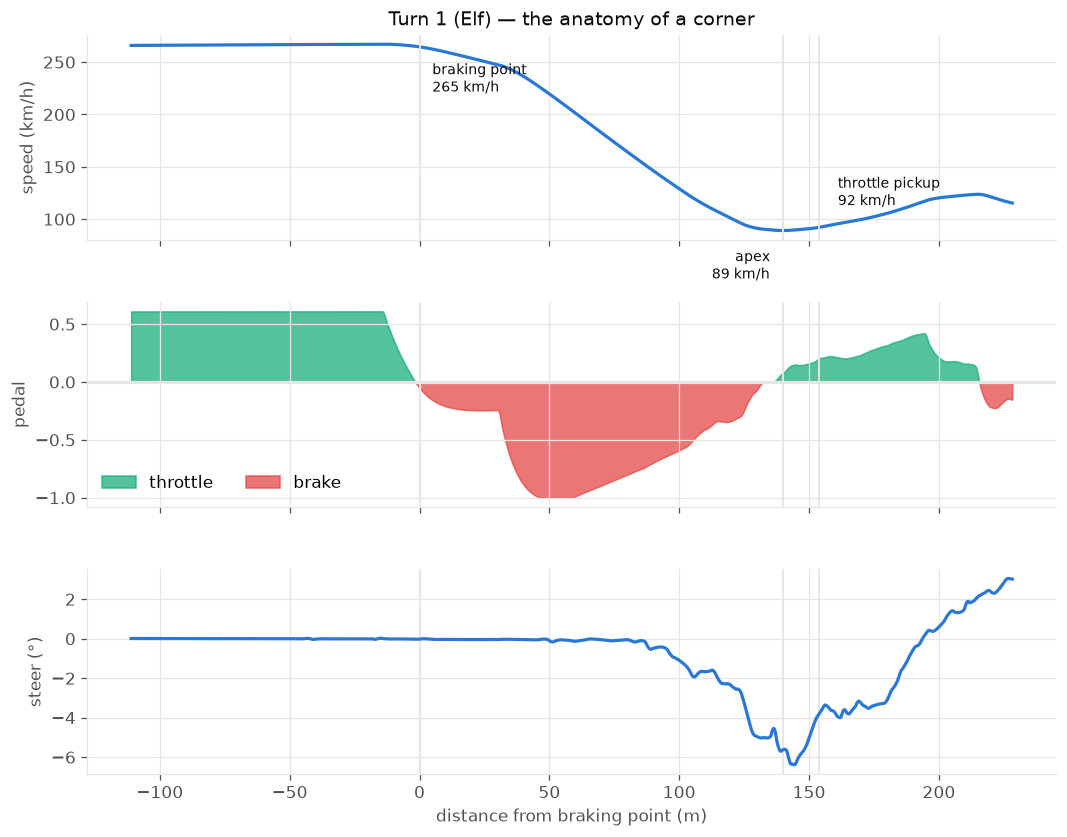

braking point → apex :   140 m in 3.18 s (265 → 89 km/h)
peak deceleration    :   3.1 g
throttle pickup      :  0.56 s after the apex


In [2]:
s_wrap = t2["s"].to_numpy() % track.length()
vx = t2["vx"].to_numpy()
brake = t2["brake"].to_numpy()
throttle = t2["throttle"].to_numpy()
steer = np.degrees(t2["steer"].to_numpy())
t = t2["time"].to_numpy()

# Locate the event: top speed, the brake application after it, the apex, the pickup.
i_vmax = int(np.argmax(vx))
i_apex = i_vmax + int(np.argmin(vx[i_vmax : i_vmax + 15_000]))
i_brk = i_vmax + int(np.argmax(brake[i_vmax:i_apex] > 0.05))
i_pick = i_apex + int(np.argmax(throttle[i_apex : i_apex + 4_000] > 0.20))

# A distance axis centred on the braking point, covering entry → exit.
w = slice(max(i_brk - 1_500, 0), i_apex + 3_000)
d = s_wrap[w] - s_wrap[i_brk]

fig, axes = plt.subplots(3, 1, figsize=(9.4, 7.4), sharex=True)

axes[0].plot(d, vx[w] * 3.6, color=BLUE)
axes[0].set_ylabel("speed (km/h)")
axes[0].set_title("Turn 1 (Elf) — the anatomy of a corner")
events = [
    (i_brk, "braking point", (8, -28)),     # below-right, clear of the title
    (i_apex, "apex", (-8, -30)),            # below-left of the minimum
    (i_pick, "throttle pickup", (12, 14)),  # above-right, clear of the apex label
]
for idx, label, (dx, dy) in events:
    x = s_wrap[idx] - s_wrap[i_brk]
    for ax in axes:
        ax.axvline(x, color=GRID, linewidth=1.2)
    axes[0].annotate(
        f"{label}\n{vx[idx] * 3.6:.0f} km/h", (x, vx[idx] * 3.6),
        xytext=(dx, dy), textcoords="offset points", color=INK, fontsize=9,
        ha="left" if dx > 0 else "right",
    )

axes[1].fill_between(d, 0, throttle[w], color=AQUA, alpha=0.75, label="throttle")
axes[1].fill_between(d, 0, -brake[w], color=RED, alpha=0.75, label="brake")
axes[1].axhline(0.0, color=GRID)
axes[1].set_ylabel("pedal")
axes[1].legend(ncols=2)

axes[2].plot(d, steer[w], color=BLUE)
axes[2].set_ylabel("steer (°)")
axes[2].set_xlabel("distance from braking point (m)")
plt.tight_layout()
plt.show()

print(f"braking point → apex : {s_wrap[i_apex] - s_wrap[i_brk]:5.0f} m "
      f"in {t[i_apex] - t[i_brk]:.2f} s ({vx[i_brk] * 3.6:.0f} → {vx[i_apex] * 3.6:.0f} km/h)")
print(f"peak deceleration    : {-t2['ax'].to_numpy()[w].min() / 9.80665:5.1f} g")
print(f"throttle pickup      : {t[i_pick] - t[i_apex]:5.2f} s after the apex")

Read the middle panel against the bottom one: the brake trace **tapers exactly as the
steering builds** — that overlap *is* trail braking, and it is not style, it is arithmetic. The
tyre can only spend one budget.

### The friction circle in action

Plot every sample of the corner in acceleration space — longitudinal $a_x$ against lateral
$a_y$ — and colour it by phase. A quasi-steady solver *assumes* the car rides this boundary;
the transient trace shows the driver actually steering around it: straight-line braking down
the $-a_x$ axis, the trail-braking arc into the lateral axis, and the drive out.

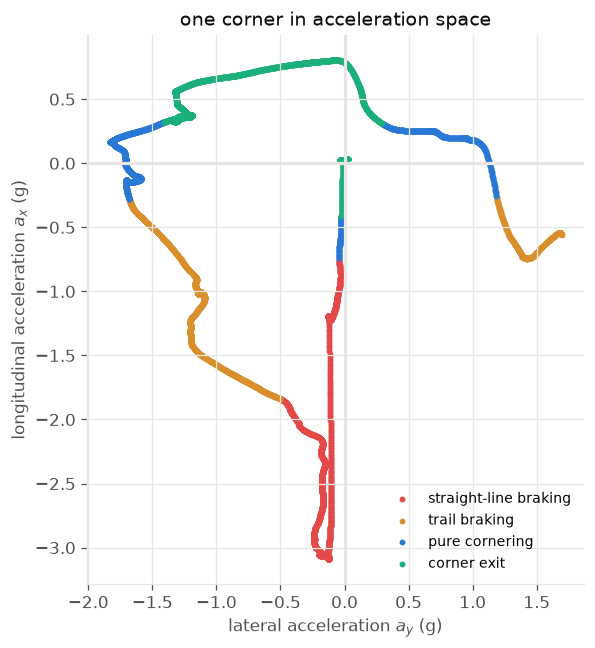

In [3]:
ax_w = t2["ax"].to_numpy()[w] / 9.80665
ay_w = t2["ay"].to_numpy()[w] / 9.80665
br_w, th_w = brake[w], throttle[w]

# Fixed categorical phases (identity, never cycled): braking / trail / cornering / exit.
phase = np.where(
    (br_w > 0.05) & (np.abs(ay_w) < 0.5), 0,
    np.where(br_w > 0.05, 1, np.where(th_w > 0.20, 3, 2)),
)
names = ["straight-line braking", "trail braking", "pure cornering", "corner exit"]
colors = [RED, AMBER, BLUE, AQUA]

fig, ax = plt.subplots(figsize=(6.6, 6.2))
for k, (nm, c) in enumerate(zip(names, colors)):
    m = phase == k
    ax.scatter(ay_w[m], ax_w[m], s=7, color=c, label=nm)
ax.axhline(0.0, color=GRID)
ax.axvline(0.0, color=GRID)
ax.set_xlabel("lateral acceleration $a_y$ (g)")
ax.set_ylabel("longitudinal acceleration $a_x$ (g)")
ax.set_title("one corner in acceleration space")
ax.set_aspect("equal")
ax.legend(loc="lower right", fontsize=9)
plt.show()

## Part 2 — car balance: understeer, oversteer, and why neutral wins

**Balance** is which axle runs out of grip first. If the front gives up first the car
*understeers* (it runs wide; stable, slow, frustrating). If the rear gives up first it
*oversteers* (the tail steps out; fast in the right hands, a spin in the wrong ones). The
scalar that captures it is the **understeer gradient** $K$: how much *extra* steering a corner
needs as speed rises. $K > 0$ understeer, $K < 0$ oversteer, $K \approx 0$ neutral.

The classic setup lever is **aero balance** — how the total downforce splits front/rear. Here
we take the same car and slide half a square metre of downforce area between the axles, total
unchanged, through the what-if override API (no files edited, full validation applied):

In [4]:
# The Limebeer car's baseline aero split (from its vehicle.yaml): total ClA = 4.5 m².
CZF, CZR = 1.98529, 2.51471
SHIFT = 0.5  # m² of downforce area moved between the axles

setups = {
    "rear-heavy aero": {
        "aero.constant.cz_front_a_m2": CZF - SHIFT,
        "aero.constant.cz_rear_a_m2": CZR + SHIFT,
    },
    "baseline": None,
    "front-heavy aero": {
        "aero.constant.cz_front_a_m2": CZF + SHIFT,
        "aero.constant.cz_rear_a_m2": CZR - SHIFT,
    },
}

laps = {}
for name, ov in setups.items():
    laps[name] = solve_lap_dataset(CAR, rl, tier="t1", sim=FAST, overrides=ov)
    k_med = float(np.nanmedian(laps[name]["understeer_gradient"].to_numpy()))
    print(f"{name:18s}  lap {laps[name].attrs['lap_time_s']:6.2f} s   "
          f"K median {k_med:+.5f} rad·s²/m")

rear-heavy aero     lap  95.17 s   K median +0.00038 rad·s²/m
baseline            lap  93.95 s   K median +0.00006 rad·s²/m


front-heavy aero    lap  96.84 s   K median -0.00025 rad·s²/m


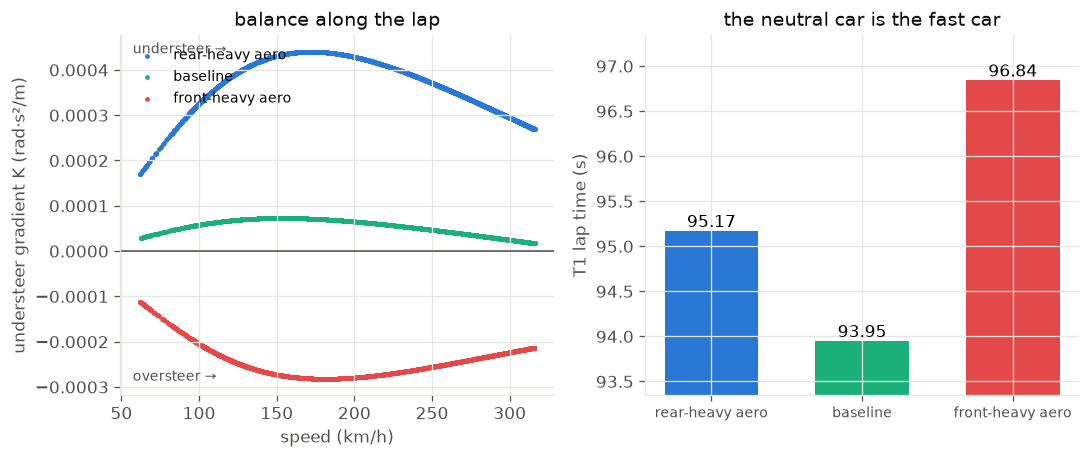

In [5]:
fig, (a, b) = plt.subplots(1, 2, figsize=(9.6, 4.1))

order = ["rear-heavy aero", "baseline", "front-heavy aero"]
colors = {"rear-heavy aero": BLUE, "baseline": AQUA, "front-heavy aero": RED}

for name in order:
    k = laps[name]["understeer_gradient"].to_numpy()
    v = laps[name]["v"].to_numpy()
    m = np.isfinite(k)
    a.scatter(v[m] * 3.6, k[m], s=4, color=colors[name], label=name)
a.axhline(0.0, color=INK2, linewidth=1.0)
a.annotate(" understeer →", (0.02, 0.95), xycoords="axes fraction", color=INK2, fontsize=9)
a.annotate(" oversteer →", (0.02, 0.04), xycoords="axes fraction", color=INK2, fontsize=9)
a.set_xlabel("speed (km/h)")
a.set_ylabel("understeer gradient K (rad·s²/m)")
a.set_title("balance along the lap")
a.legend(fontsize=9)

times = [laps[n].attrs["lap_time_s"] for n in order]
bars = b.bar(order, times, color=[colors[n] for n in order], width=0.62)
b.set_ylim(min(times) - 0.6, max(times) + 0.5)
b.set_ylabel("T1 lap time (s)")
b.set_title("the neutral car is the fast car")
b.tick_params(axis="x", labelsize=8.5)
for rect, v in zip(bars, times):
    b.text(rect.get_x() + rect.get_width() / 2, v, f"{v:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

t_base = laps["baseline"].attrs["lap_time_s"]
assert all(laps[n].attrs["lap_time_s"] >= t_base for n in order), \
    "baseline (near-neutral) should be the fastest of the three"

Both directions lose lap time, and the sign of $K$ tells you *why*: pile the downforce on
the rear and the front washes out first ($K$ rises — understeer); pile it on the front and the
rear becomes the weak axle ($K$ goes negative — oversteer, and the solver must leave lateral
margin for it). The baseline sits near neutral and wins. This is the daily loop of a race
engineer, compressed: *change one setup number → read the balance → read the lap time.*

**Try it yourself** — every knob goes through the same override API:

- `{"brakes.balance_bar": 0.55}` — move brake bias rearward and watch corner-entry behaviour;
- `{"chassis.mass_kg": 750.0}` — ballast: roughly linear seconds per lap;
- `{"aero.constant.cx_a_m2": 1.1}` — trim drag and trade top speed against the corners.

**Next:** [08 · the transient tier](08_transient_t2.ipynb) is the full tour of the solver these
traces came from; [07 · the QSS tier](07_qss_t1.ipynb) covers the per-wheel physics that
defines $K$; the theory pages ([`driver.md`](../docs/theory/driver.md),
[`t1-trim.md`](../docs/theory/t1-trim.md)) carry the equations and citations.